<center><h1>Artificial Neural Networks Theory</h1></center>
<center><i>Part of the Knowledge Journal Project</i></center>

---

**Author:** Augusto Damasceno  
**Project Link:** [github.com/augustodamasceno/knowledge-journal](https://github.com/augustodamasceno/knowledge-journal)  
**Last Updated:** April 20, 2026

---
<div style="text-align: right;">
<small>Copyright © 2026, Augusto Damasceno</small><br>
<small>SPDX-License-Identifier: <code>BSD-2-Clause</code></small>
</div>

# 1. Artificial Neuron

## 1.1 Equations

A single artificial neuron computes a weighted sum of its inputs, adds a bias term, and then passes the result through an activation function.

For a 2D input space (like our visualizations with $x_1$ and $x_2$), the pre-activation linear combination $Z$ is:

$$Z = w_1 x_1 + w_2 x_2 + b$$

The final output of the neuron applies the chosen activation function $f(z)$ to this linear combination:

$$Output = f(Z)$$

For a generalized neuron with $n$ inputs, the equation is written as a dot product:

$$Z = \sum_{i=1}^{n} w_i x_i + b$$

---

### Activation Functions

The activation function $f(z)$ dictates the shape of the decision boundary and how the neuron maps the pre-activation value $Z$ to its final output.

#### 1. Linear (Identity)
Passes the value through without any changes. It creates a strictly planar (linear) activation space.
$$f(z) = z$$

#### 2. Sigmoid
Squashes the output into a range between 0 and 1. It is useful for binary classification and representing probabilities, but suffers from vanishing gradients at extreme values.
$$f(z) = \frac{1}{1 + e^{-z}}$$

#### 3. Tanh (Hyperbolic Tangent)
Squashes the output into a range between -1 and 1. It is zero-centered, which often makes optimization easier than the Sigmoid function.
$$f(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

#### 4. ReLU (Rectified Linear Unit)
Outputs the input directly if it is positive; otherwise, it outputs zero. It is computationally efficient and helps mitigate the vanishing gradient problem, but can suffer from "dying" neurons if values drop below zero.
$$f(z) = \max(0, z)$$

#### 5. LeakyReLU
A variant of ReLU that allows a small, non-zero gradient when the input is negative, preventing the "dying ReLU" problem. In our visualization, we used a negative slope ($\alpha$) of $0.1$.
$$f(z) = \begin{cases} z & \text{if } z \geq 0 \\ \alpha z & \text{if } z < 0 \end{cases}$$

#### 6. ELU (Exponential Linear Unit)
Similar to LeakyReLU, but uses a smooth exponential curve for negative values rather than a straight line. This smoothness can push mean unit activations closer to zero, speeding up learning.
$$f(z) = \begin{cases} z & \text{if } z \geq 0 \\ \alpha (e^z - 1) & \text{if } z < 0 \end{cases}$$

In [4]:
import torch
import torch.nn as nn
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

class SingleNeuron(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        self.activation = activation

    def forward(self, x):
        return self.activation(self.linear(x))

activations = {
    'Linear': nn.Identity(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1),
    'ELU': nn.ELU()
}

x1_range = np.linspace(-10, 10, 100)
x2_range = np.linspace(-10, 10, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

inputs = torch.tensor(np.c_[X1.ravel(), X2.ravel()], dtype=torch.float32)

np.random.seed(42)
X_class0 = np.random.randn(20, 2) - [4, 4]
X_class1 = np.random.randn(20, 2) + [4, 4]

fig = go.FigureWidget(make_subplots(
    rows=2, cols=3, 
    subplot_titles=list(activations.keys()),
    horizontal_spacing=0.05, 
    vertical_spacing=0.1
))

heatmap_traces = []

for i, (name, act_func) in enumerate(activations.items()):
    row = (i // 3) + 1
    col = (i % 3) + 1
    
    heatmap = go.Heatmap(
        x=x1_range, 
        y=x2_range, 
        z=np.zeros((100, 100)), 
        colorscale='RdBu_r',
        zsmooth='best',
        showscale=(col == 3)
    )
    fig.add_trace(heatmap, row=row, col=col)
    heatmap_traces.append(fig.data[-1])
    
    fig.add_trace(go.Scatter(
        x=X_class0[:,0], y=X_class0[:,1], 
        mode='markers',
        marker=dict(color='#00008B', symbol='circle', size=8, line=dict(width=1, color='white')),
        showlegend=False
    ), row=row, col=col)
    
    fig.add_trace(go.Scatter(
        x=X_class1[:,0], y=X_class1[:,1], 
        mode='markers',
        marker=dict(color='#8B0000', symbol='square', size=8, line=dict(width=1, color='white')),
        showlegend=False
    ), row=row, col=col)

fig.update_layout(
    height=800, 
    width=1200, 
    title_text="Single Neuron Activation Space with Linearly Separable Data",
    margin=dict(l=40, r=40, t=80, b=40)
)

for i in range(1, 7):
    fig['layout'][f'xaxis{i}'].update(zeroline=True, zerolinecolor='black', zerolinewidth=2, title="Input x1")
    fig['layout'][f'yaxis{i}'].update(zeroline=True, zerolinecolor='black', zerolinewidth=2, title="Input x2")

w1_slider = widgets.FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1, description='Weight 1:')
w2_slider = widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='Weight 2:')
b_slider = widgets.FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description='Bias:')

def update_plots(change):
    w1, w2, b = w1_slider.value, w2_slider.value, b_slider.value
    fig.layout.title.text = f"Single Neuron Activation Space (w1={w1:.1f}, w2={w2:.1f}, b={b:.1f})"
    
    with fig.batch_update():
        for idx, (name, act_func) in enumerate(activations.items()):
            model = SingleNeuron(act_func)
            
            with torch.no_grad():
                model.linear.weight = nn.Parameter(torch.tensor([[w1, w2]], dtype=torch.float32))
                model.linear.bias = nn.Parameter(torch.tensor([b], dtype=torch.float32))
                outputs = model(inputs).view(100, 100).numpy()
            
            heatmap_traces[idx].z = outputs

w1_slider.observe(update_plots, names='value')
w2_slider.observe(update_plots, names='value')
b_slider.observe(update_plots, names='value')

ui = widgets.HBox([w1_slider, w2_slider, b_slider])

update_plots(None)

display(ui, fig)

FigureWidget({
    'data': [{'colorscale': [[0.0, 'rgb(5,48,97)'], [0.1, 'rgb(33,102,172)'],
                             [0.2, 'rgb(67,147,195)'], [0.3, 'rgb(146,197,222)'],
                             [0.4, 'rgb(209,229,240)'], [0.5, 'rgb(247,247,247)'],
                             [0.6, 'rgb(253,219,199)'], [0.7, 'rgb(244,165,130)'],
                             [0.8, 'rgb(214,96,77)'], [0.9, 'rgb(178,24,43)'],
                             [1.0, 'rgb(103,0,31)']],
              'showscale': False,
              'type': 'heatmap',
              'uid': '6e691a5a-35dd-42db-aeec-12723143d27e',
              'x': {'bdata': ('AAAAAAAAJMBDYt7OkJgjwIbEvJ0hMS' ... 'ydITEjQERi3s6QmCNAAAAAAAAAJEA='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAJMBDYt7OkJgjwIbEvJ0hMS' ... 'ydITEjQERi3s6QmCNAAAAAAAAAJEA='),
                    'dtype': 'f8'},
              'yaxis': 'y',
              'z': {'bdata': ('AAAAAIDeTj5g3s4+0CYbP2DeTj8AS4' ...

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Configuration of the activation functions
activations = {
    'Linear': nn.Identity(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1),
    'ELU': nn.ELU()
}

# 2. Setup the input range
# A domain of [-5, 5] is standard for visualizing saturation and rectification points
x = torch.linspace(-5, 5, 500)

# 3. Initialize the grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# 4. Iterate and plot
for i, (name, module) in enumerate(activations.items()):
    with torch.no_grad():
        y = module(x)
    
    ax = axes[i]
    ax.plot(x.numpy(), y.numpy(), color='#1f77b4', linewidth=2.5)
    
    # Visual cues: origin lines and grid
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    ax.set_title(name, fontweight='bold')
    
    # Normalize y-axis scale based on function range
    if name in ['Sigmoid', 'Tanh']:
        ax.set_ylim([-1.2, 1.2])
    else:
        ax.set_ylim([-2, 5])

plt.tight_layout()
plt.show()

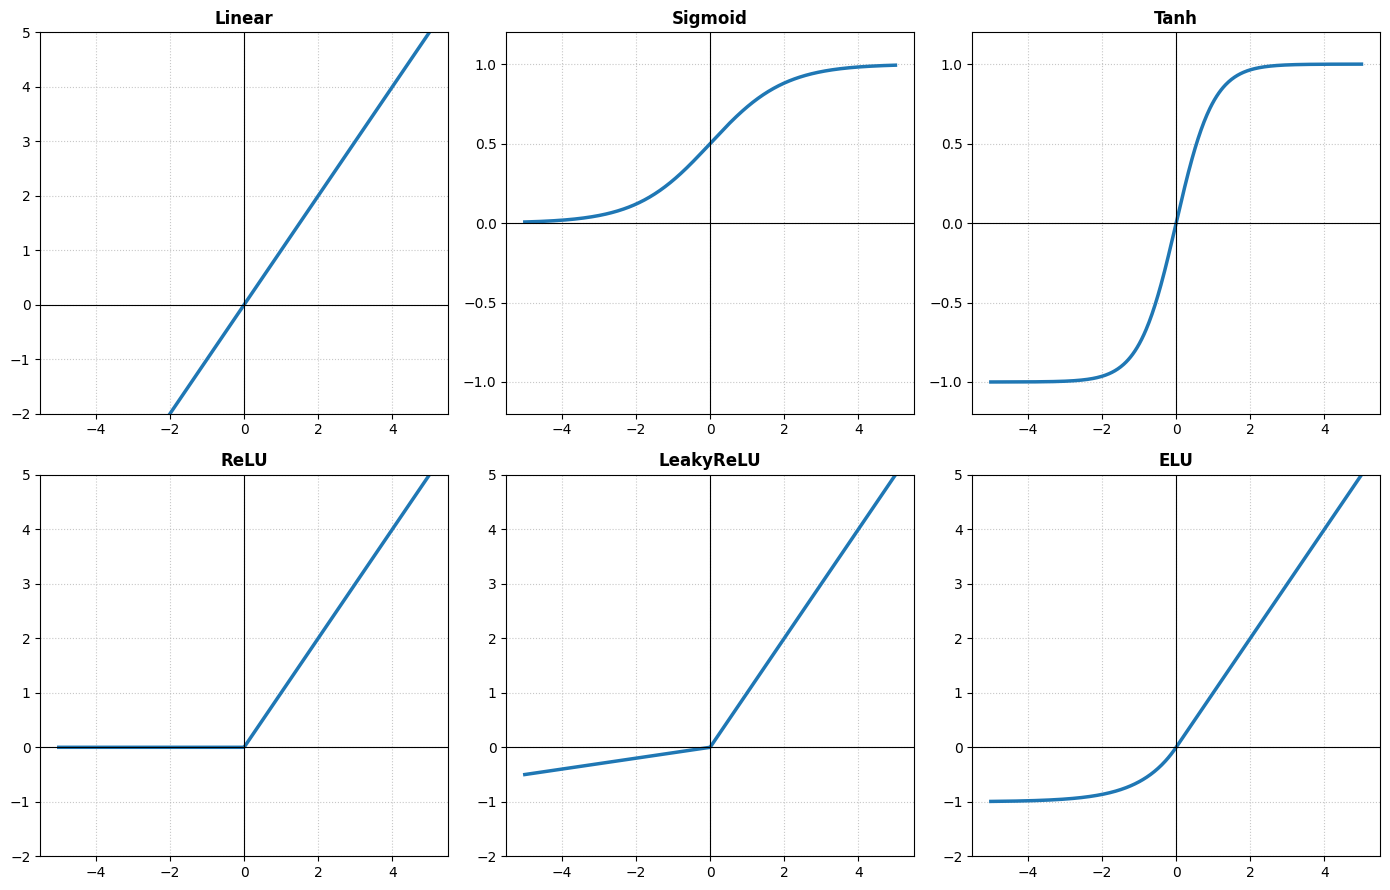

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Configuration of the activation functions
activations = {
    'Linear': nn.Identity(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1),
    'ELU': nn.ELU()
}

# 2. Setup the input range
# A domain of [-5, 5] is standard for visualizing saturation and rectification points
x = torch.linspace(-5, 5, 500)

# 3. Initialize the grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# 4. Iterate and plot
for i, (name, module) in enumerate(activations.items()):
    with torch.no_grad():
        y = module(x)
    
    ax = axes[i]
    ax.plot(x.numpy(), y.numpy(), color='#1f77b4', linewidth=2.5)
    
    # Visual cues: origin lines and grid
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(True, linestyle=':', alpha=0.7)
    
    ax.set_title(name, fontweight='bold')
    
    # Normalize y-axis scale based on function range
    if name in ['Sigmoid', 'Tanh']:
        ax.set_ylim([-1.2, 1.2])
    else:
        ax.set_ylim([-2, 5])

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

class XORNet(nn.Module):
    def __init__(self, activation):
        super().__init__()
        # Hidden layer with 2 neurons
        self.hidden = nn.Linear(2, 2)
        self.activation = activation
        # Single output neuron to combine the hidden features
        self.output = nn.Linear(2, 1)

    def forward(self, x):
        hidden_features = self.activation(self.hidden(x))
        return self.output(hidden_features)

activations = {
    'Linear': nn.Identity(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1),
    'ELU': nn.ELU()
}

# Adjusted domain range suited for XOR points
x1_range = np.linspace(-2.5, 2.5, 100)
x2_range = np.linspace(-2.5, 2.5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

inputs = torch.tensor(np.c_[X1.ravel(), X2.ravel()], dtype=torch.float32)

# XOR Dataset
X_class0 = np.array([[-1, -1], [1, 1]])
X_class1 = np.array([[-1, 1], [1, -1]])

fig = go.FigureWidget(make_subplots(
    rows=2, cols=3, 
    subplot_titles=list(activations.keys()),
    horizontal_spacing=0.05, 
    vertical_spacing=0.1
))

heatmap_traces = []

for i, (name, act_func) in enumerate(activations.items()):
    row = (i // 3) + 1
    col = (i % 3) + 1
    
    heatmap = go.Heatmap(
        x=x1_range, 
        y=x2_range, 
        z=np.zeros((100, 100)), 
        colorscale='RdBu_r',
        zmid=0,  # Critical for keeping the decision boundary centered visually
        zsmooth='best',
        showscale=(col == 3)
    )
    fig.add_trace(heatmap, row=row, col=col)
    heatmap_traces.append(fig.data[-1])
    
    fig.add_trace(go.Scatter(
        x=X_class0[:,0], y=X_class0[:,1], 
        mode='markers',
        marker=dict(color='#00008B', symbol='circle', size=10, line=dict(width=1.5, color='white')),
        showlegend=False
    ), row=row, col=col)
    
    fig.add_trace(go.Scatter(
        x=X_class1[:,0], y=X_class1[:,1], 
        mode='markers',
        marker=dict(color='#8B0000', symbol='square', size=10, line=dict(width=1.5, color='white')),
        showlegend=False
    ), row=row, col=col)

fig.update_layout(
    height=800, 
    width=1200, 
    title_text="Two-Neuron Hidden Layer Decision Boundary (XOR Problem)",
    margin=dict(l=40, r=40, t=80, b=40)
)

for i in range(1, 7):
    fig['layout'][f'xaxis{i}'].update(zeroline=True, zerolinecolor='black', zerolinewidth=1, title="Input x1")
    fig['layout'][f'yaxis{i}'].update(zeroline=True, zerolinecolor='black', zerolinewidth=1, title="Input x2")

# UI Configuration for 9 parameters (2 Hidden Neurons + 1 Output Neuron)
style = {'description_width': 'initial'}
layout = widgets.Layout(width='300px')

# Hidden Neuron 1
h1_w1 = widgets.FloatSlider(value=1.5, min=-5.0, max=5.0, step=0.1, description='w11:', style=style, layout=layout)
h1_w2 = widgets.FloatSlider(value=-1.5, min=-5.0, max=5.0, step=0.1, description='w12:', style=style, layout=layout)
h1_b  = widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='b1:', style=style, layout=layout)

# Hidden Neuron 2
h2_w1 = widgets.FloatSlider(value=-1.5, min=-5.0, max=5.0, step=0.1, description='w21:', style=style, layout=layout)
h2_w2 = widgets.FloatSlider(value=1.5, min=-5.0, max=5.0, step=0.1, description='w22:', style=style, layout=layout)
h2_b  = widgets.FloatSlider(value=-1.0, min=-5.0, max=5.0, step=0.1, description='b2:', style=style, layout=layout)

# Output Neuron
o_w1 = widgets.FloatSlider(value=2.0, min=-5.0, max=5.0, step=0.1, description='w_out1:', style=style, layout=layout)
o_w2 = widgets.FloatSlider(value=2.0, min=-5.0, max=5.0, step=0.1, description='w_out2:', style=style, layout=layout)
o_b  = widgets.FloatSlider(value=-0.5, min=-5.0, max=5.0, step=0.1, description='b_out:', style=style, layout=layout)

def update_plots(change):
    with fig.batch_update():
        for idx, (name, act_func) in enumerate(activations.items()):
            model = XORNet(act_func)
            
            with torch.no_grad():
                # Shape [out_features, in_features] -> [2, 2]
                model.hidden.weight = nn.Parameter(torch.tensor([
                    [h1_w1.value, h1_w2.value], 
                    [h2_w1.value, h2_w2.value]
                ], dtype=torch.float32))
                # Shape [out_features] -> [2]
                model.hidden.bias = nn.Parameter(torch.tensor([h1_b.value, h2_b.value], dtype=torch.float32))
                
                # Shape [out_features, in_features] -> [1, 2]
                model.output.weight = nn.Parameter(torch.tensor([[o_w1.value, o_w2.value]], dtype=torch.float32))
                # Shape [1]
                model.output.bias = nn.Parameter(torch.tensor([o_b.value], dtype=torch.float32))
                
                outputs = model(inputs).view(100, 100).numpy()
            
            heatmap_traces[idx].z = outputs

# Register callbacks
sliders = [h1_w1, h1_w2, h1_b, h2_w1, h2_w2, h2_b, o_w1, o_w2, o_b]
for slider in sliders:
    slider.observe(update_plots, names='value')

# Organize UI into a clean grid
ui = widgets.VBox([
    widgets.HTML("<b>Hidden Neuron 1 Parameters:</b>"),
    widgets.HBox([h1_w1, h1_w2, h1_b]),
    widgets.HTML("<b>Hidden Neuron 2 Parameters:</b>"),
    widgets.HBox([h2_w1, h2_w2, h2_b]),
    widgets.HTML("<b>Output Neuron Parameters:</b>"),
    widgets.HBox([o_w1, o_w2, o_b])
])

update_plots(None)
display(ui, fig)

FigureWidget({
    'data': [{'colorscale': [[0.0, 'rgb(5,48,97)'], [0.1, 'rgb(33,102,172)'],
                             [0.2, 'rgb(67,147,195)'], [0.3, 'rgb(146,197,222)'],
                             [0.4, 'rgb(209,229,240)'], [0.5, 'rgb(247,247,247)'],
                             [0.6, 'rgb(253,219,199)'], [0.7, 'rgb(244,165,130)'],
                             [0.8, 'rgb(214,96,77)'], [0.9, 'rgb(178,24,43)'],
                             [1.0, 'rgb(103,0,31)']],
              'showscale': False,
              'type': 'heatmap',
              'uid': 'af128df8-739c-4210-9127-5451b05b2650',
              'x': {'bdata': ('AAAAAAAABMBDYt7OkJgDwIbEvJ0hMQ' ... 'ydITEDQERi3s6QmANAAAAAAAAABEA='),
                    'dtype': 'f8'},
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAABMBDYt7OkJgDwIbEvJ0hMQ' ... 'ydITEDQERi3s6QmANAAAAAAAAABEA='),
                    'dtype': 'f8'},
              'yaxis': 'y',
              'z': {'bdata': ('AACQwAAAkMAAAJDAAACQwAAAkMAAAJ' ...

In [6]:
100 - 90

10

In [11]:
np.log10(1)

np.float64(0.0)